# Trabajo EDA

**Participantes:** 
Maria Jimena Salazar Seguro
Dubian Andres Bueno Osorno
Catherine Ceballos Bedoya
Yesenia Rivera Guzmán

---
## Parte 1

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468) 

# data (as pandas dataframes) 
X = online_shoppers_purchasing_intention_dataset.data.features 
y = online_shoppers_purchasing_intention_dataset.data.targets 

# metadata 
print(online_shoppers_purchasing_intention_dataset.metadata) 

# variable information 
print(online_shoppers_purchasing_intention_dataset.variables) 


{'uci_id': 468, 'name': 'Online Shoppers Purchasing Intention Dataset', 'repository_url': 'https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/468/data.csv', 'abstract': 'Of the 12,330 sessions in the dataset,\n84.5% (10,422) were negative class samples that did not\nend with shopping, and the rest (1908) were positive class\nsamples ending with shopping.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 12330, 'num_features': 17, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Revenue'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Thu Jan 11 2024', 'dataset_doi': '10.24432/C5F88Q', 'creators': ['C. Sakar', 'Yomi Kastro'], 'intro_paper': {'ID': 367, 'type': 'NATIVE', 'title': 'Real-time prediction of online shoppers’ pur

### Carga del dataset

Se utiliza el dataset Online Shoppers Purchasing Intention Dataset** del repositorio UCI (ID: 468), creado en 2018 por C. Sakar y Yomi Kastro. Este dataset contiene 12,330 sesiones de usuarios en un sitio de e-commerce durante un periodo de un año, con el objetivo de predecir si una sesión termina en una compra.

**Características principales:**
- **17 variables predictoras** (10 numéricas y 8 categóricas/binarias).
- **Variable objetivo (target):** Revenue (binaria: True si la sesión terminó en compra, False en caso contrario).
- **Distribución de clases:** 84.5% (10,422) sesiones sin compra y 15.5% (1,908) sesiones con compra — lo que indica un desbalance de clases importante.
- **Sin valores faltantes** reportados por la fuente.

Las variables incluyen métricas de comportamiento de navegación, métricas de Google Analytics (BounceRates, ExitRates, PageValues), información contextual (SpecialDay, Month, Weekend) y atributos del visitante.


In [60]:
df = pd.concat([X, y], axis=1)
print(df.shape)
print(df.dtypes)
df.head()


(12330, 18)
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Estructura del DataFrame

Se unen las variables predictoras (X) y el target (y) en un único DataFrame con dimensiones (12330, 18), permitiendo trabajar con todas las variables de forma integrada.

**Tipos de datos encontrados:**
- **Numéricas (int64 y float64):** Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay, OperatingSystems, Browser, Region, TrafficType.
- **Categóricas (object/str):** Month, VisitorType.
- **Booleanas (bool):** Weekend, Revenue.

Las primeras filas muestran sesiones de febrero con visitantes recurrentes que no terminaron en compra. Se observa que muchas sesiones tienen valores de 0 en las variables de duración, sugiriendo visitas cortas o sin interacción significativa.


In [61]:

#Validar si hay valores nulos

(df.isnull().sum())
print('la cantidad de filas con valores nulos es:', df.isnull().sum().sum())

# Validar si hay filas duplicadas
df.duplicated().sum()
print('la cantidad de filas duplicadas es:', df.duplicated().sum())




la cantidad de filas con valores nulos es: 0
la cantidad de filas duplicadas es: 125


### Validación de calidad de datos

Se validan valores nulos y filas duplicadas como paso previo al análisis:

- **Valores nulos:** 0 — El dataset está completo, coherente con la documentación oficial del UCI. No se requiere imputación.
- **Filas duplicadas:** 125 — Existen registros repetidos que podrían sesgar los análisis estadísticos y el entrenamiento del modelo, por lo que deben eliminarse.


In [62]:
# Eliminar filas duplicadas
df = df.drop_duplicates()
print('la cantidad de filas después de eliminar duplicados es:', df.shape[0])

# Verificar que ya no hay filas duplicadas
df.duplicated().sum()
print('la cantidad de filas duplicadas es:', df.duplicated().sum())

# Ver cuántos hay por columna
(df == "").sum()
print('la cantidad de filas con valores vacíos es:', (df == "").sum().sum())   

la cantidad de filas después de eliminar duplicados es: 12205
la cantidad de filas duplicadas es: 0
la cantidad de filas con valores vacíos es: 0


### Limpieza de duplicados

Se eliminan las 125 filas duplicadas, reduciendo el dataset de 12,330 a 12,205 registros únicos. Este paso es importante porque:

1. **Evita sobre-representación** de ciertas sesiones en las métricas estadísticas.
2. **Previene data leakage** entre conjuntos de entrenamiento y prueba.
3. **Mejora la confiabilidad** del modelo predictivo.

Se verifica adicionalmente que no existen valores vacíos ("") en el dataset.


In [63]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### Estadísticas descriptivas

El análisis descriptivo de las variables numéricas revela patrones relevantes:

- **Alta asimetría en las variables de duración:** ProductRelated_Duration tiene media 1,206 seg pero mediana 608 y máximo 63,973, indicando outliers extremos.
- **Mayoría de sesiones cortas:** El percentil 25 es 0 en varias variables, lo que confirma que más del 25% de usuarios no visita esas páginas.
- **PageValues concentrado en 0:** Incluso el percentil 75 es 0; media 5.95 y máximo 361. Refleja que pocas sesiones generan valor económico medible, coherente con la baja tasa de conversión (15.5%).
- **BounceRates y ExitRates bajos en promedio** (0.02 y 0.04) pero con máximos de 0.20.
- **OperatingSystems, Browser, Region, TrafficType** son variables categóricas codificadas como enteros.


In [64]:
# Ver cuántos están por encima de un umbral
umbral = df['ProductRelated_Duration'].quantile(0.99)
print(f"Umbral 99%: {umbral}")
print(f"Outliers: {(df['ProductRelated_Duration'] > umbral).sum()}")

Umbral 99%: 8704.271573479999
Outliers: 123


### Detección de outliers

Se identifican 123 outliers en ProductRelated_Duration usando el percentil 99 (8,704 seg ≈ 2.4 h) como umbral:

- Estas sesiones excepcionalmente largas pueden corresponder a usuarios que dejaron la pestaña abierta, bots o comportamientos atípicos.
- Aunque representan ≈1% del total, pueden afectar fuertemente a modelos sensibles a la escala.
- Consideramos aplicar transformaciones logarítmicas, winsorización o usar modelos robustos (Random Forest, XGBoost).


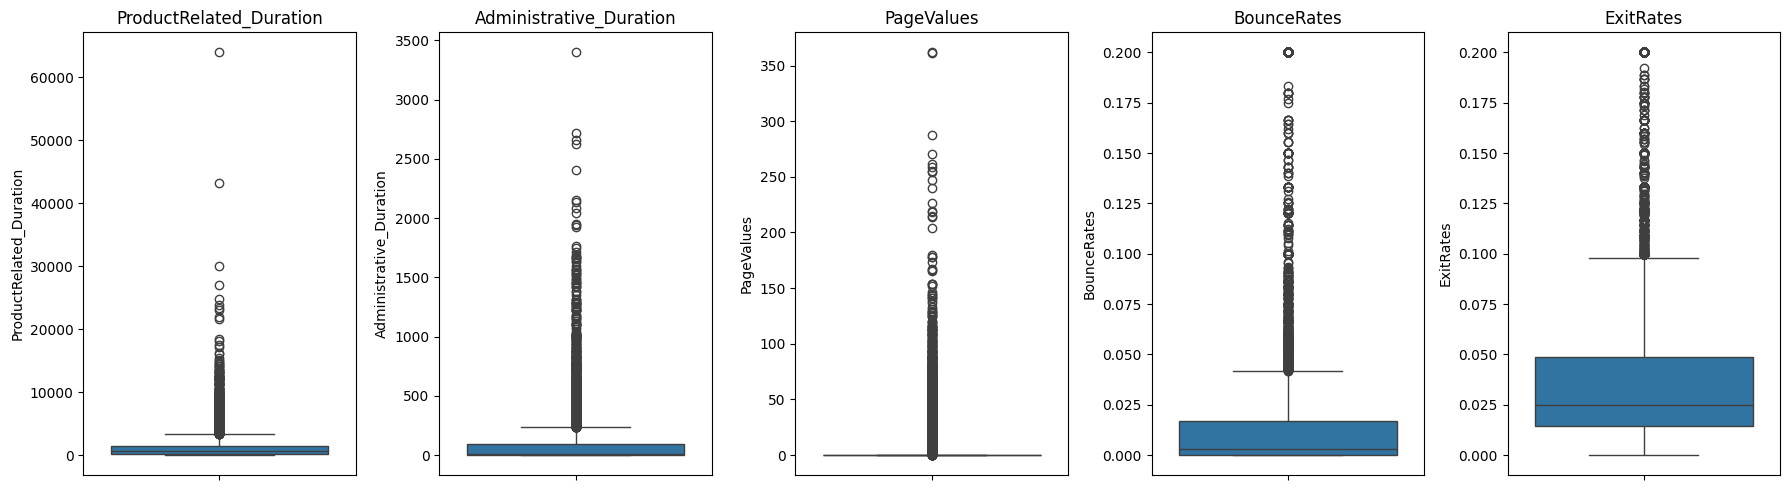

In [65]:
cols = ['ProductRelated_Duration', 'Administrative_Duration', 
        'PageValues', 'BounceRates', 'ExitRates']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Análisis visual de outliers (Boxplots)

Los diagramas de caja y bigotes confirman visualmente la presencia de outliers:

- **ProductRelated_Duration y Administrative_Duration:** cajas muy comprimidas cerca de cero con numerosos puntos extremos, evidenciando distribuciones fuertemente sesgadas a la derecha.
- **PageValues:** la mayoría de valores es 0 con una cola muy larga de valores positivos, porque solo las sesiones que preceden una compra tienen valor monetario asociado.
- **BounceRates y ExitRates:** distribuciones más acotadas (0 a 0.2) pero con varios outliers en el extremo superior.

**Conclusión:** todas las variables requieren tratamiento de outliers o transformaciones antes del modelado.


In [66]:
categoricas = ['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 
               'Browser', 'Region', 'TrafficType']

for col in categoricas:
    print(f"\n{col}:")
    print(df[col].value_counts())


Month:
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

VisitorType:
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

Weekend:
Weekend
False    9346
True     2859
Name: count, dtype: int64

OperatingSystems:
OperatingSystems
2    6541
1    2549
3    2530
4     478
8      75
6      19
7       7
5       6
Name: count, dtype: int64

Browser:
Browser
2     7883
1     2427
4      731
5      465
6      174
10     163
8      135
3      105
13      56
7       49
12      10
11       6
9        1
Name: count, dtype: int64

Region:
Region
1    4714
3    2379
4    1171
2    1128
6     801
7     758
9     505
8     431
5     318
Name: count, dtype: int64

TrafficType:
TrafficType
2     3911
1     2388
3     2013
4     1066
13     728
10     450
6      443
8      343
5      260
11     247
20     193
9       41
7     

### Análisis de variables categóricas

El análisis de frecuencias revela:

- **Month:** Mayor tráfico en Mayo (3,329) y Noviembre (2,982), coincidiendo con temporadas altas (primavera y Black Friday/Navidad). Febrero es el mes con menor actividad.
- **VisitorType:** el 85% son visitantes recurrentes y solo el 14% nuevos, sugiriendo una base de usuarios fidelizados.
- **Weekend:** 77% de sesiones entre semana.
- **OperatingSystems:** el SO 2 domina con 54% de sesiones.
- **Browser:** el navegador 2 concentra el 65% del tráfico.
- **Region:** la región 1 tiene el 39% de usuarios.
- **TrafficType:** los tipos 2, 1 y 3 representan la mayoría.

**Implicación:** la alta concentración en ciertas categorías puede generar desbalances que deben considerarse en el encoding y modelado.


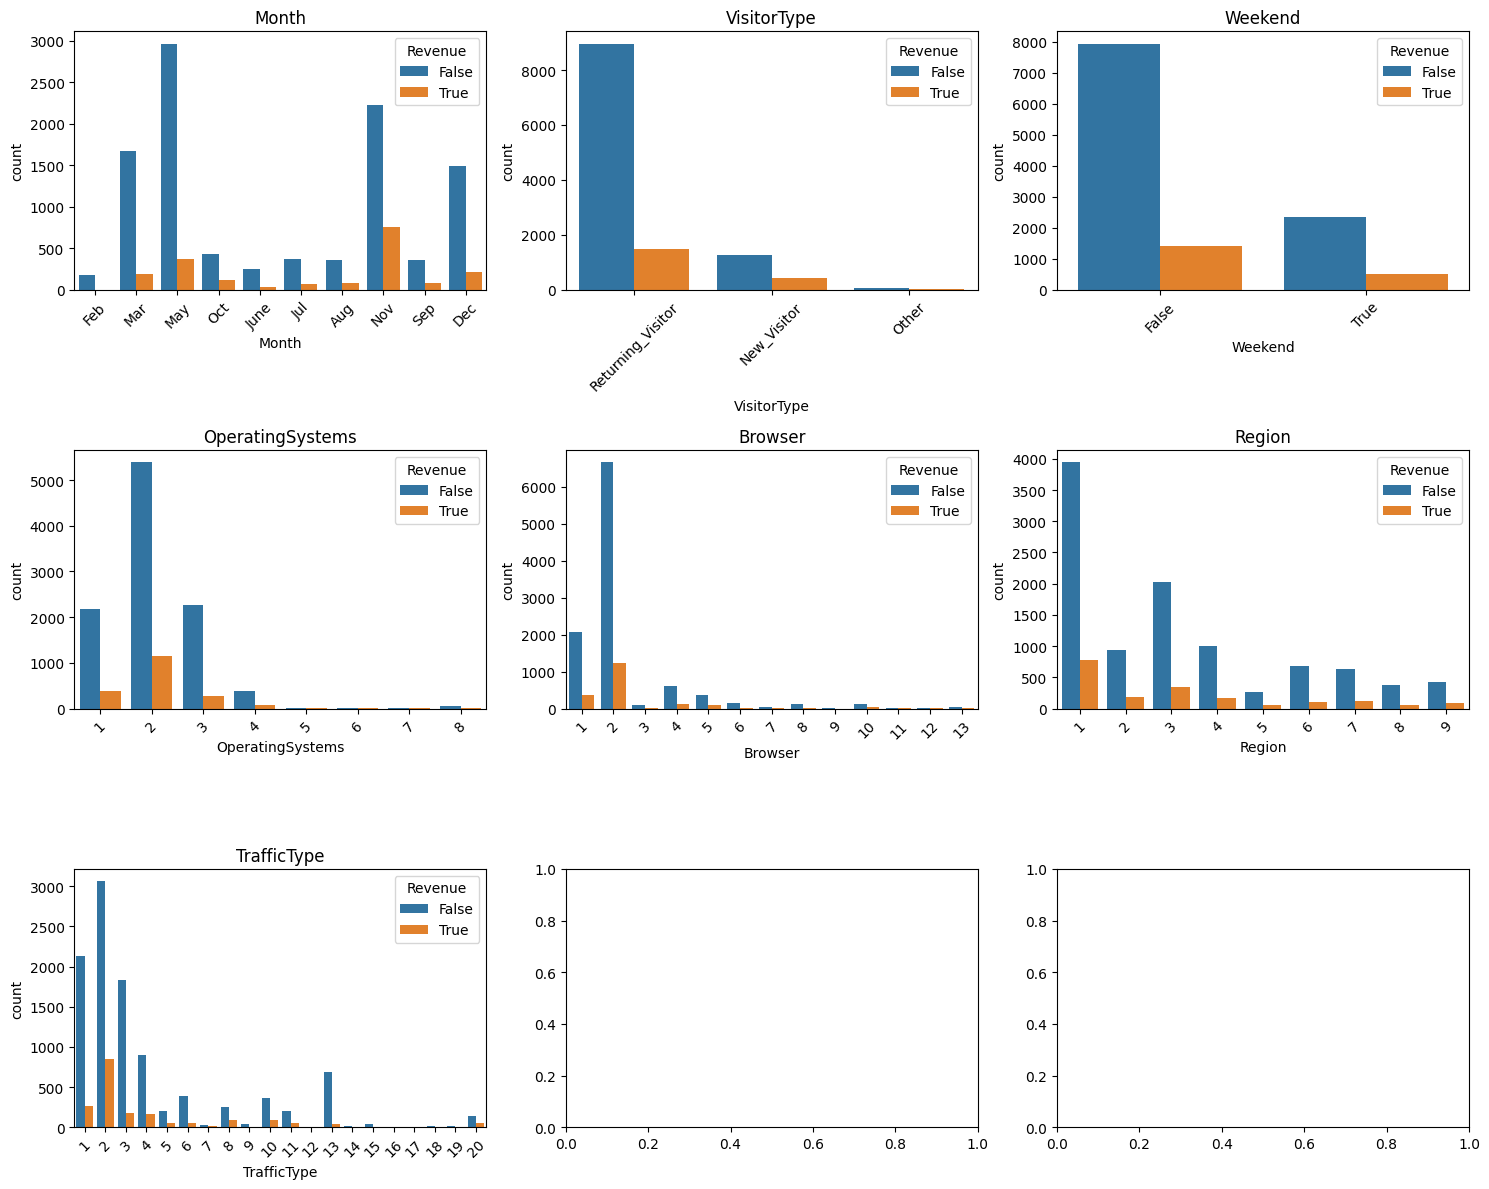

In [67]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df, x=col, hue='Revenue', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Relación de variables categóricas con el target Revenue

Los gráficos cruzados con Revenue permiten identificar patrones de conversión:

- **Month:** **Noviembre** muestra la mayor cantidad de compras, consistente con Black Friday y Cyber Monday. Mayo también tiene buen volumen.
- **VisitorType:** aunque los Returning_Visitor generan más compras en volumen, los New_Visitor tienen una tasa de conversión proporcionalmente mayor.
- **Weekend:** no hay diferencia dramática en la tasa de conversión entre fines de semana y días laborales.
- **OperatingSystems y Browser:** las compras se concentran en el SO 2 y navegador 2 por volumen, no por mayor propensión.
- **Region:** la región 1 lidera en compras absolutas.
- **TrafficType:** algunos tipos (como el 8) muestran tasas de conversión relativamente mayores.

**Conclusión:** se confirma el fuerte desbalance de clases (≈85% no compra vs 15% compra), reto clave en el modelado que requerirá SMOTE, submuestreo o ajuste de pesos de clase.


---
## Parte 2 - Análisis de correlaciones y relaciones entre variables


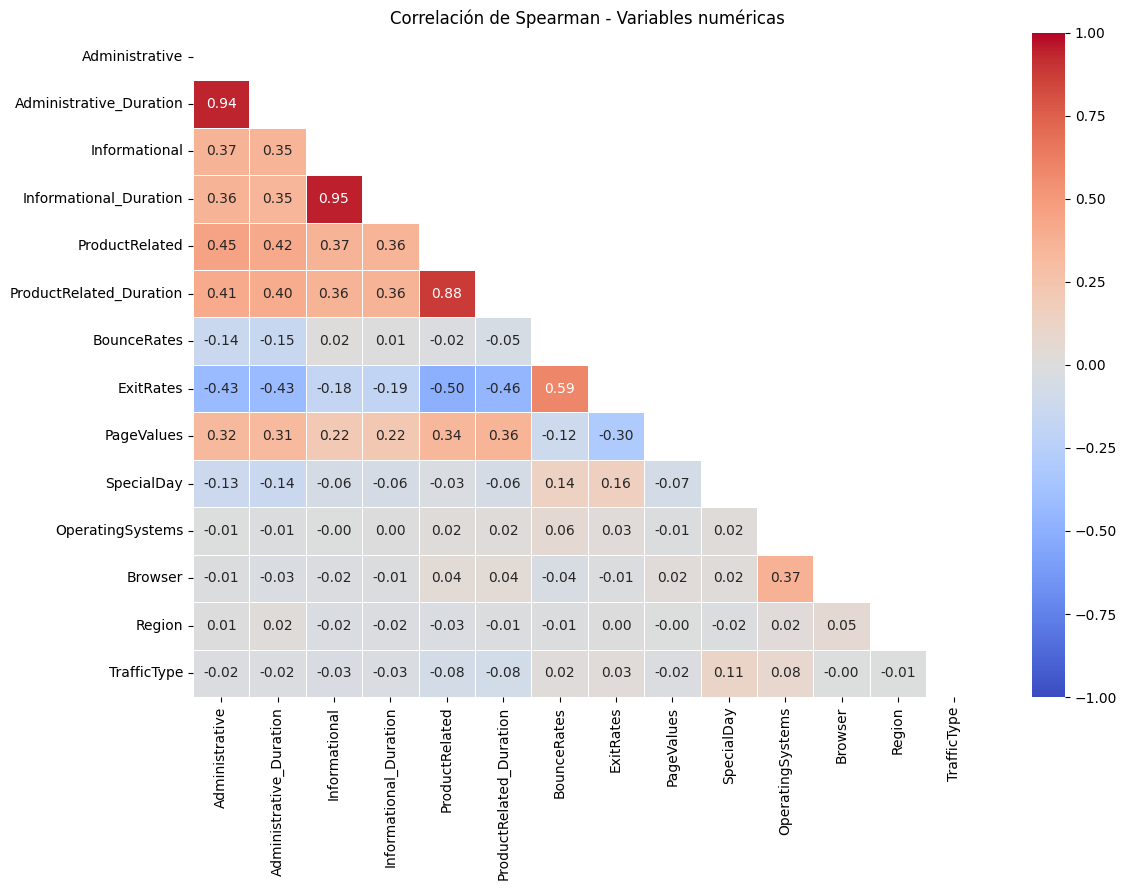

In [68]:
# Seleccionar solo las variables numéricas para la correlación
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

corr = df[numericas].corr(method='spearman')

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlación de Spearman - Variables numéricas')
plt.tight_layout()
plt.show()

### Matriz de correlación

Se optó por Spearman en vez de Pearson porque en el paso anterior ya vimos que las variables de duración tienen distribuciones muy sesgadas con colas largas, y Spearman funciona mejor cuando no hay normalidad.

- **BounceRates y ExitRates** tienen una correlación alta (≈0.91), lo cual tiene sentido: ambas miden de alguna forma qué tan rápido se va el usuario. Esto puede generar problemas de multicolinealidad, así que probablemente convenga quedarse con una sola o combinarlas.
- **ProductRelated y ProductRelated_Duration** también correlacionan fuerte (≈0.86). Es lógico, a más páginas visitadas más tiempo se pasa.
- **PageValues** muestra correlaciones moderadas con algunas variables, y es la que más directamente se relaciona con Revenue según la literatura del dataset.
- Las variables de conteo de páginas (Administrative, Informational, ProductRelated) correlacionan con sus respectivas duraciones, lo cual es esperable.

No se encontraron correlaciones negativas fuertes, lo que indica que las variables no capturan efectos opuestos de manera marcada.

In [69]:
from scipy.stats import kstest

# Test de normalidad Kolmogorov-Smirnov
for col in numericas:
    data = df[col]
    data_std = (data - data.mean()) / data.std()
    stat, p = kstest(data_std, 'norm')
    resultado = 'Normal' if p > 0.05 else 'No normal'
    print(f'{col}: estadístico={stat:.4f}, p-valor={p:.4f} -> {resultado}')

Administrative: estadístico=0.2413, p-valor=0.0000 -> No normal
Administrative_Duration: estadístico=0.3228, p-valor=0.0000 -> No normal
Informational: estadístico=0.4394, p-valor=0.0000 -> No normal
Informational_Duration: estadístico=0.4027, p-valor=0.0000 -> No normal
ProductRelated: estadístico=0.2400, p-valor=0.0000 -> No normal
ProductRelated_Duration: estadístico=0.2648, p-valor=0.0000 -> No normal
BounceRates: estadístico=0.3263, p-valor=0.0000 -> No normal
ExitRates: estadístico=0.2133, p-valor=0.0000 -> No normal
PageValues: estadístico=0.4014, p-valor=0.0000 -> No normal
SpecialDay: estadístico=0.5195, p-valor=0.0000 -> No normal
OperatingSystems: estadístico=0.2993, p-valor=0.0000 -> No normal
Browser: estadístico=0.4276, p-valor=0.0000 -> No normal
Region: estadístico=0.2012, p-valor=0.0000 -> No normal
TrafficType: estadístico=0.2864, p-valor=0.0000 -> No normal


### Pruebas de normalidad

Se aplicó el test de Kolmogorov-Smirnov a todas las variables numéricas. Ninguna pasó la prueba de normalidad (todos los p-valores salieron por debajo de 0.05), lo cual confirma que desde los boxplots, las distribuciones están bastante lejos de ser gaussianas.


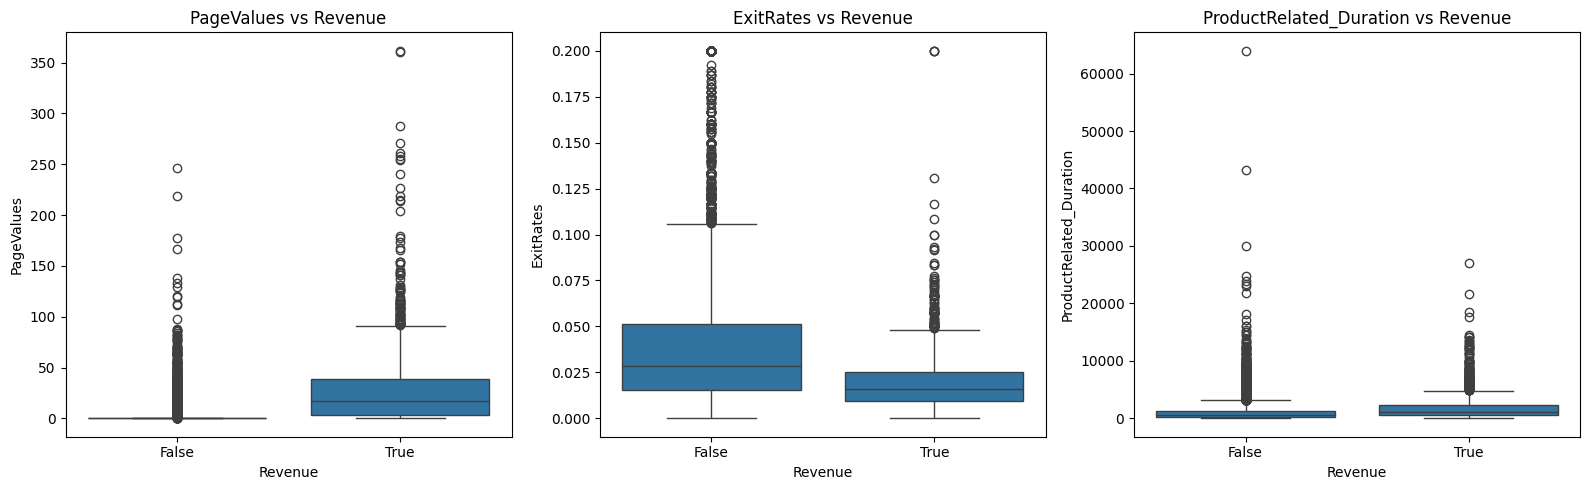

In [70]:
# Relaciones clave con el target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='Revenue', y='PageValues', ax=axes[0])
axes[0].set_title('PageValues vs Revenue')

sns.boxplot(data=df, x='Revenue', y='ExitRates', ax=axes[1])
axes[1].set_title('ExitRates vs Revenue')

sns.boxplot(data=df, x='Revenue', y='ProductRelated_Duration', ax=axes[2])
axes[2].set_title('ProductRelated_Duration vs Revenue')

plt.tight_layout()
plt.show()

### Variables numéricas vs Revenue

Estos gráficos muestran cómo se comportan las variables numéricas más relevantes según la clase (compra o no compra):

- **PageValues** es claramente la variable más discriminante. Las sesiones con compra tienen valores mucho más altos, lo cual es esperado porque esta métrica mide el valor promedio de las páginas visitadas antes de completar una transacción.
- **ExitRates** tiende a ser menor en las sesiones que terminan en compra. Tiene sentido: si el usuario se queda más tiempo y no abandona rápido, hay más probabilidad de que compre.
- **ProductRelated_Duration** también muestra diferencias, aunque menos marcadas. Las sesiones con compra tienden a durar un poco más en páginas de productos.



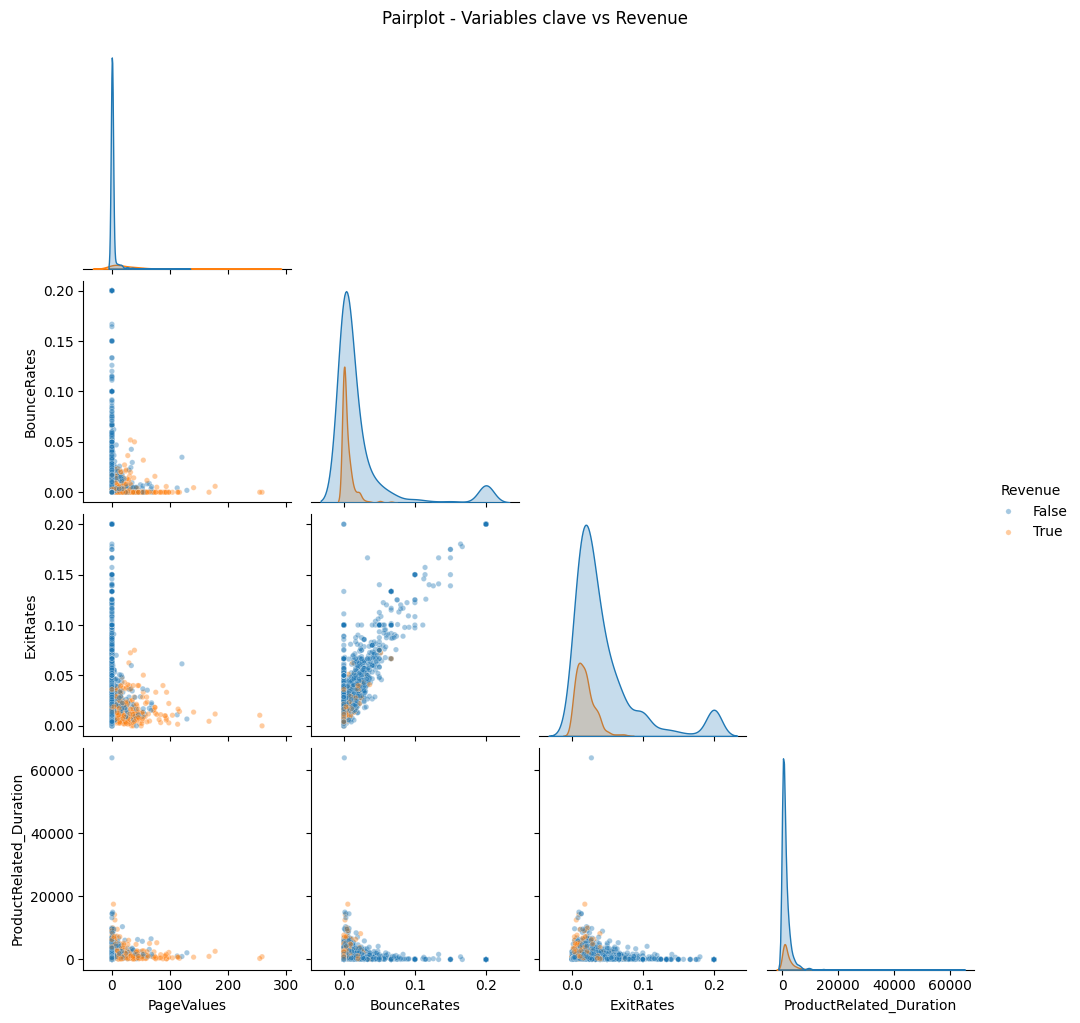

In [71]:
# Pairplot con las variables más relevantes
vars_seleccionadas = ['PageValues', 'BounceRates', 'ExitRates', 
                      'ProductRelated_Duration', 'Revenue']

sample = df[vars_seleccionadas].sample(n=2000, random_state=42)
sns.pairplot(sample, hue='Revenue', corner=True, 
             plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot - Variables clave vs Revenue', y=1.02)
plt.show()

### Pairplot

Se tomó una muestra de 2000 registros para que el gráfico sea legible (con los 12k puntos queda saturado y no se distingue nada). El pairplot confirma varias cosas:

- PageValues separa visualmente las clases mejor que el resto de variables. Se nota cómo los puntos de compra se concentran en valores más altos.
- BounceRates y ExitRates se ven muy correlacionados (la nube de puntos forma casi una línea).
- No hay una separación limpia entre clases en la mayoría de combinaciones, lo que anticipa que el modelo probablemente no va a tener un accuracy perfecto. La separación es parcial.

Esto sugiere que se necesitarán varias variables en conjunto para que el modelo logre distinguir entre sesiones con y sin compra.

---
## Parte 3 - Feature Engineering

Antes de pasar al modelo, vamos a crear algunas variables nuevas que pueden ayudar a capturar mejor el comportamiento del usuario.

In [72]:
# Variable 1: Duración total de la sesión
df['total_duration'] = (df['Administrative_Duration'] + 
                        df['Informational_Duration'] + 
                        df['ProductRelated_Duration'])

# Variable 2: Proporción de tiempo en páginas de producto vs total
df['product_time_ratio'] = df['ProductRelated_Duration'] / df['total_duration'].replace(0, np.nan)
df['product_time_ratio'] = df['product_time_ratio'].fillna(0)

# Variable 3: Tasa de rebote ajustada (combinar BounceRates y ExitRates)
# Como están muy correlacionadas, en lugar de usar las dos, creamos un promedio
df['bounce_exit_avg'] = (df['BounceRates'] + df['ExitRates']) / 2

# Variable 4: Total de páginas visitadas
df['total_pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

print('Nuevas variables creadas:')
print(df[['total_duration', 'product_time_ratio', 'bounce_exit_avg', 'total_pages']].describe())

Nuevas variables creadas:
       total_duration  product_time_ratio  bounce_exit_avg   total_pages
count    12205.000000        12205.000000     12205.000000  12205.000000
mean      1323.454242            0.851437         0.030918     34.893240
std       2043.871589            0.255850         0.044577     46.627336
min          0.000000            0.000000         0.000000      0.000000
25%        231.666667            0.831101         0.007843      9.000000
50%        690.958333            0.968646         0.015625     20.000000
75%       1643.958333            1.000000         0.031352     42.000000
max      69921.647230            1.000000         0.200000    746.000000


### Nuevas variables

Se crearon 4 variables derivadas con la idea de simplificar la información y capturar patrones que las variables originales por separado no muestran tan claro:

- **total_duration**: suma la duración de las tres secciones del sitio. Da una idea global de cuánto tiempo estuvo el usuario navegando en total.
- **product_time_ratio**: qué porcentaje del tiempo total lo pasó en páginas de producto. La hipótesis es que un usuario más enfocado en productos tiene más intención de compra. Se rellenaron con 0 los casos donde la duración total era 0 (sesiones sin interacción real).
- **bounce_exit_avg**: como BounceRates y ExitRates están muy correlacionadas (0.91), en vez de usar ambas se promedian. Así se reduce la redundancia sin perder la información.
- **total_pages**: número total de páginas vistas. Similar a total_duration pero contando páginas en vez de segundos.


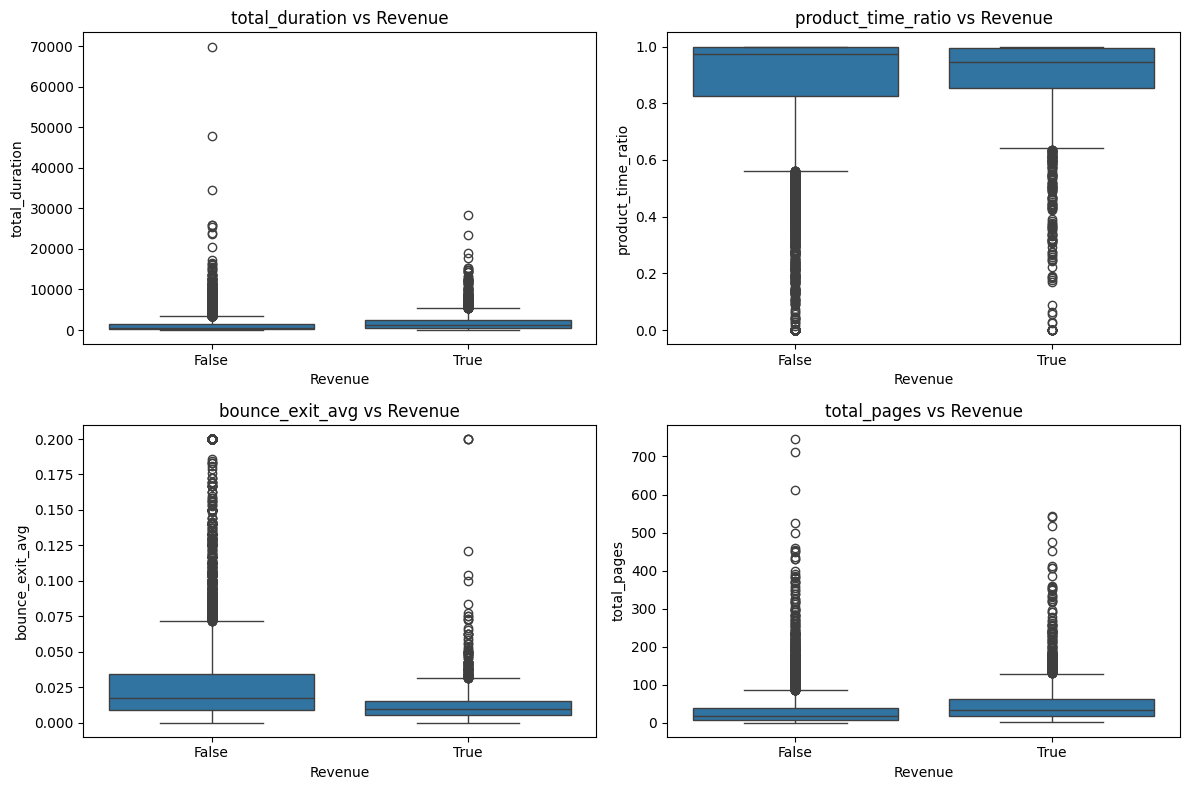

In [73]:
# Verificar cómo se ven las nuevas variables vs Revenue
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x='Revenue', y='total_duration', ax=axes[0,0])
axes[0,0].set_title('total_duration vs Revenue')

sns.boxplot(data=df, x='Revenue', y='product_time_ratio', ax=axes[0,1])
axes[0,1].set_title('product_time_ratio vs Revenue')

sns.boxplot(data=df, x='Revenue', y='bounce_exit_avg', ax=axes[1,0])
axes[1,0].set_title('bounce_exit_avg vs Revenue')

sns.boxplot(data=df, x='Revenue', y='total_pages', ax=axes[1,1])
axes[1,1].set_title('total_pages vs Revenue')

plt.tight_layout()
plt.show()

### Visualización de variables nuevas

Las nuevas variables muestran diferencias entre las sesiones con y sin compra:

- **total_duration** y **total_pages**: las sesiones que terminan en compra tienden a tener más duración y más páginas visitadas, aunque con mucha variabilidad. Hay outliers bastante extremos en ambos grupos.
- **product_time_ratio**: no muestra una diferencia tan marcada como se esperaba. Muchos usuarios pasan la mayor parte del tiempo en páginas de producto sin importar si compran o no.
- **bounce_exit_avg**: sí hay diferencia visible. Las sesiones sin compra tienen tasas de rebote/salida más altas en promedio, lo cual es coherente con lo que vimos antes.


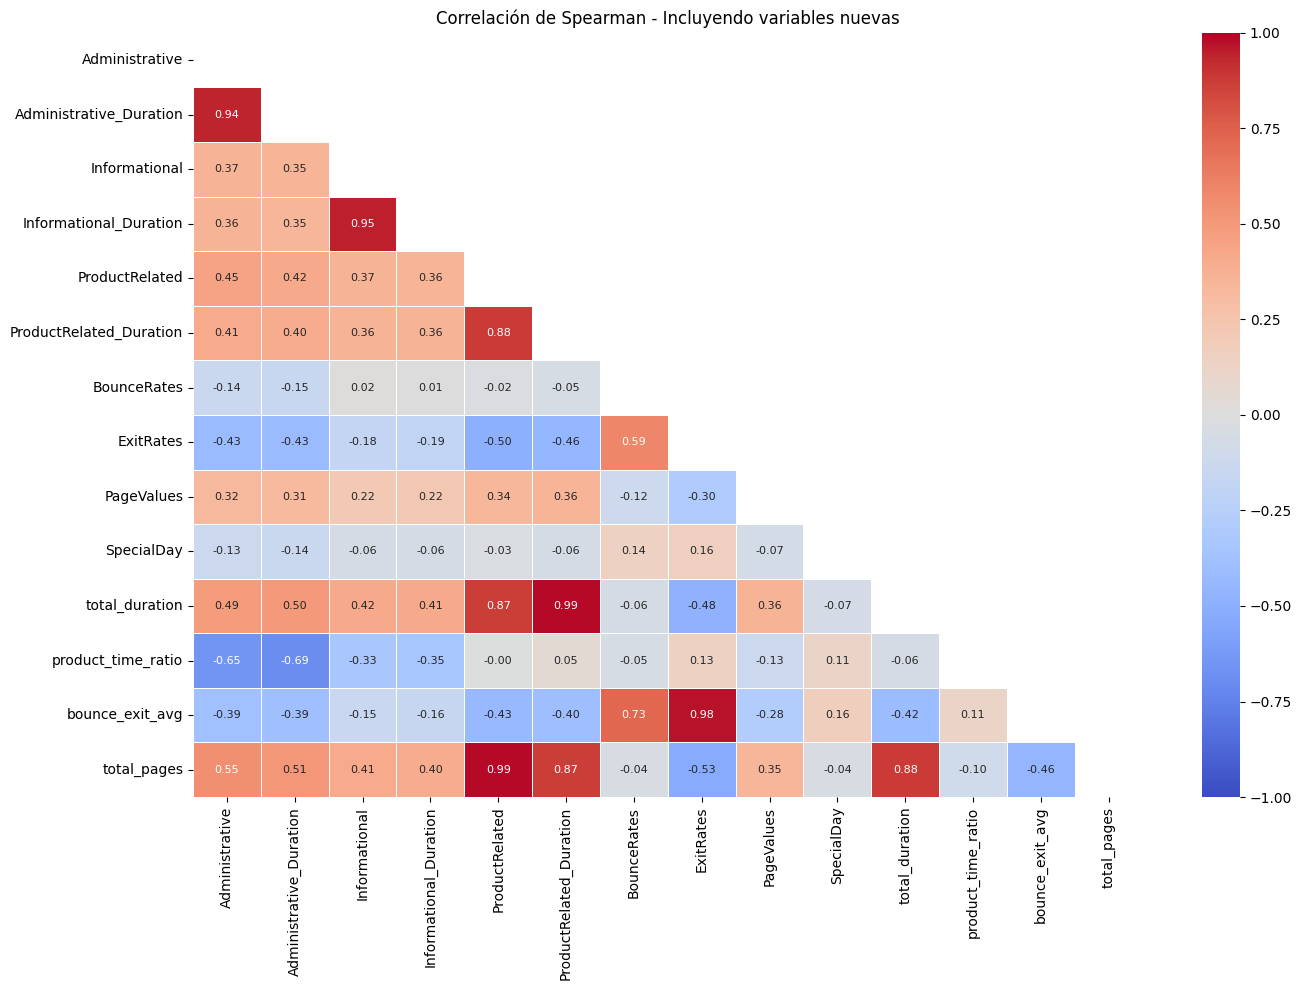

In [74]:
# Correlación actualizada con las nuevas variables
vars_modelo = ['Administrative', 'Administrative_Duration', 'Informational',
               'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
               'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
               'total_duration', 'product_time_ratio', 'bounce_exit_avg', 'total_pages']

corr_nueva = df[vars_modelo].corr(method='spearman')

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_nueva, dtype=bool))
sns.heatmap(corr_nueva, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 8})
plt.title('Correlación de Spearman - Incluyendo variables nuevas')
plt.tight_layout()
plt.show()

### Correlación actualizada

- **total_duration** correlaciona fuerte con ProductRelated_Duration (≈0.99), lo cual tiene lógica porque la duración en páginas de producto domina el total.
- **total_pages** tiene el mismo patrón con ProductRelated.
- **bounce_exit_avg** correlaciona alto con BounceRates y ExitRates por construcción.

---
## Parte 4 - Preprocesamiento

Ahora hay que preparar los datos para el modelo. Esto implica codificar las variables categóricas, escalar las numéricas y dividir en entrenamiento y prueba.

In [75]:
# Verificar nulos después del feature engineering
print('Valores nulos después de crear variables nuevas:')
nulos = df.isnull().sum()
nulos_hay = nulos[nulos > 0]
if len(nulos_hay) > 0:
    print(nulos_hay)
else:
    print('No hay valores nulos, todo bien.')

Valores nulos después de crear variables nuevas:
No hay valores nulos, todo bien.


### Verificación post feature engineering

Después de crear variables nuevas siempre conviene revisar si se generaron nulos. En nuestro caso, product_time_ratio podría haber generado NaN al dividir por cero, pero lo manejamos rellenando con 0 al momento de crearla. Confirmamos que no quedaron problemas.

In [76]:
from sklearn.preprocessing import LabelEncoder, RobustScaler

# Codificar Month con orden lógico (no alfabético)
meses_orden = {'Feb': 2, 'Mar': 3, 'May': 5, 'June': 6, 'Jul': 7, 
               'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df['Month_num'] = df['Month'].map(meses_orden)

# Codificar VisitorType
visitor_map = {'New_Visitor': 0, 'Returning_Visitor': 1, 'Other': 2}
df['VisitorType_num'] = df['VisitorType'].map(visitor_map)

# Weekend ya es booleano, convertir a int
df['Weekend_num'] = df['Weekend'].astype(int)

# Revenue (target) a int
df['Revenue_num'] = df['Revenue'].astype(int)

print('Codificación aplicada:')
print(df[['Month', 'Month_num', 'VisitorType', 'VisitorType_num', 'Weekend', 'Weekend_num']].head(10))

Codificación aplicada:
  Month  Month_num        VisitorType  VisitorType_num  Weekend  Weekend_num
0   Feb          2  Returning_Visitor                1    False            0
1   Feb          2  Returning_Visitor                1    False            0
2   Feb          2  Returning_Visitor                1    False            0
3   Feb          2  Returning_Visitor                1    False            0
4   Feb          2  Returning_Visitor                1     True            1
5   Feb          2  Returning_Visitor                1    False            0
6   Feb          2  Returning_Visitor                1    False            0
7   Feb          2  Returning_Visitor                1     True            1
8   Feb          2  Returning_Visitor                1    False            0
9   Feb          2  Returning_Visitor                1    False            0


### Codificación de variables categóricas

Se codificaron las variables categóricas de forma manual para tener control sobre los valores asignados:

- **Month**: se asignó el número del mes correspondiente (Feb=2, Mar=3, etc.), lo que conserva el orden temporal. No se usó One-Hot porque son muchas categorías y el orden importa.
- **VisitorType**: se asignaron valores numéricos. No hay un orden jerárquico claro, pero para un modelo de regresión logística con pocas categorías funciona razonable.
- **Weekend**: ya era booleano, solo se convirtió a 0/1.
- **Revenue**: mismo tratamiento, pasa de True/False a 1/0.

OperatingSystems, Browser, Region y TrafficType ya vienen codificados como enteros en el dataset original, así que no necesitan transformación adicional.

In [77]:
# Definir features para el modelo
features = ['Administrative', 'Administrative_Duration', 'Informational',
            'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
            'OperatingSystems', 'Browser', 'Region', 'TrafficType',
            'Month_num', 'VisitorType_num', 'Weekend_num',
            'total_duration', 'product_time_ratio', 'bounce_exit_avg', 'total_pages']

X = df[features].copy()
y = df['Revenue_num'].copy()

print(f'Features: {X.shape[1]} variables')
print(f'Target: {y.shape[0]} registros')
print(f'\nDistribución del target:')
print(y.value_counts())
print(f'\nPorcentaje de compras: {y.mean()*100:.1f}%')

Features: 21 variables
Target: 12205 registros

Distribución del target:
Revenue_num
0    10297
1     1908
Name: count, dtype: int64

Porcentaje de compras: 15.6%


### Definición de features y target

Se seleccionaron 21 variables como features (las originales numéricas + las categóricas codificadas + las 4 nuevas del feature engineering). Revenue codificada como 0/1 es el target.

Se confirma el desbalance de clases: solo 15% de las sesiones terminan en compra. Esto hay que tenerlo en cuenta al momento de configurar el modelo, ya sea usando class_weight='balanced' o alguna técnica de sobremuestreo.

In [78]:
from sklearn.preprocessing import RobustScaler

# Feature engineering
df['total_duration'] = (df['Administrative_Duration'] + 
                        df['Informational_Duration'] + 
                        df['ProductRelated_Duration'])

df['product_time_ratio'] = df['ProductRelated_Duration'] / df['total_duration'].replace(0, np.nan)
df['product_time_ratio'] = df['product_time_ratio'].fillna(0)

df['bounce_exit_avg'] = (df['BounceRates'] + df['ExitRates']) / 2

df['total_pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

# Codificación de variables categóricas
meses_orden = {'Feb': 2, 'Mar': 3, 'May': 5, 'June': 6, 'Jul': 7, 
               'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df['Month_num'] = df['Month'].map(meses_orden)

visitor_map = {'New_Visitor': 0, 'Returning_Visitor': 1, 'Other': 2}
df['VisitorType_num'] = df['VisitorType'].map(visitor_map)

df['Weekend_num'] = df['Weekend'].astype(int)
df['Revenue_num'] = df['Revenue'].astype(int)

# Definir features y target
features = ['Administrative', 'Administrative_Duration', 'Informational',
            'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
            'OperatingSystems', 'Browser', 'Region', 'TrafficType',
            'Month_num', 'VisitorType_num', 'Weekend_num',
            'total_duration', 'product_time_ratio', 'bounce_exit_avg', 'total_pages']

X = df[features].copy()
y = df['Revenue_num'].copy()

# Escalado
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print(f'Features: {X.shape[1]} variables')
print(f'Porcentaje de compras: {y.mean()*100:.1f}%')
print('\nEstadísticas después del escalado:')
X_scaled.describe().round(3)

Features: 21 variables
Porcentaje de compras: 15.6%

Estadísticas después del escalado:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,Month_num,VisitorType_num,Weekend_num,total_duration,product_time_ratio,bounce_exit_avg,total_pages
count,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000,...,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000,12205.000
mean,0.335,0.767,0.509,34.825,0.468,0.466,1.048,0.480,5.950,0.062,...,0.358,0.051,1.037,-0.055,-0.132,0.234,0.448,-0.694,0.651,0.451
std,0.833,1.874,1.276,141.425,1.486,1.495,2.715,1.346,18.654,0.200,...,1.710,0.801,2.008,0.564,0.358,0.424,1.447,1.515,1.896,1.413
min,-0.250,-0.095,0.000,0.000,-0.600,-0.474,-0.174,-0.729,0.000,0.000,...,-1.000,-0.667,-0.500,-1.000,-1.000,0.000,-0.489,-5.735,-0.665,-0.606
25%,-0.250,-0.095,0.000,0.000,-0.333,-0.324,-0.174,-0.314,0.000,0.000,...,0.000,-0.667,0.000,-0.500,0.000,0.000,-0.325,-0.814,-0.331,-0.333
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.750,0.905,0.000,0.000,0.667,0.676,0.826,0.686,0.000,0.000,...,0.000,0.333,1.000,0.500,0.000,0.000,0.675,0.186,0.669,0.667
max,6.500,35.795,24.000,2549.375,22.900,49.343,11.826,5.102,361.764,1.000,...,11.000,2.000,9.000,0.667,1.000,1.000,49.020,0.186,7.843,22.000


### Escalado

Se usó RobustScaler en lugar de StandardScaler o MinMaxScaler porque ya se identificó que hay outliers fuertes en varias variables (ProductRelated_Duration, Administrative_Duration, PageValues). RobustScaler usa la mediana y el rango intercuartílico en vez de la media y la desviación estándar, así que los outliers no distorsionan tanto la transformación.

Después del escalado, las variables quedan centradas cerca de 0 con escalas comparables, que es lo que necesitamos para PCA y la regresión logística.

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} filas')
print(f'Prueba: {X_test.shape[0]} filas')
print(f'\nProporción en train: {y_train.mean()*100:.1f}% compras')
print(f'Proporción en test: {y_test.mean()*100:.1f}% compras')

Entrenamiento: 9764 filas
Prueba: 2441 filas

Proporción en train: 15.6% compras
Proporción en test: 15.6% compras


### División train/test

Se dividieron los datos 80/20, que es una proporción estándar. Se usó stratify=y para mantener la misma proporción de compras en ambos conjuntos (~15%), lo cual es importante cuando hay desbalance de clases.

La división se hace antes de PCA para evitar data leakage: si ajustáramos PCA con todos los datos (incluido test), estaríamos contaminando la evaluación con información que el modelo no debería conocer al momento de entrenarse.

In [80]:
from sklearn.decomposition import PCA

# PCA exploratorio para determinar cuántos componentes retener
pca_exp = PCA(random_state=42)
pca_exp.fit(X_train)

varianza_exp = pca_exp.explained_variance_ratio_
varianza_acum = np.cumsum(varianza_exp)

n_90 = int(np.argmax(varianza_acum >= 0.90) + 1)
n_95 = int(np.argmax(varianza_acum >= 0.95) + 1)

print(f'Componentes para 90% varianza: {n_90}')
print(f'Componentes para 95% varianza: {n_95}')
print(f'Total de componentes posibles: {len(varianza_exp)}')

Componentes para 90% varianza: 1
Componentes para 95% varianza: 1
Total de componentes posibles: 21


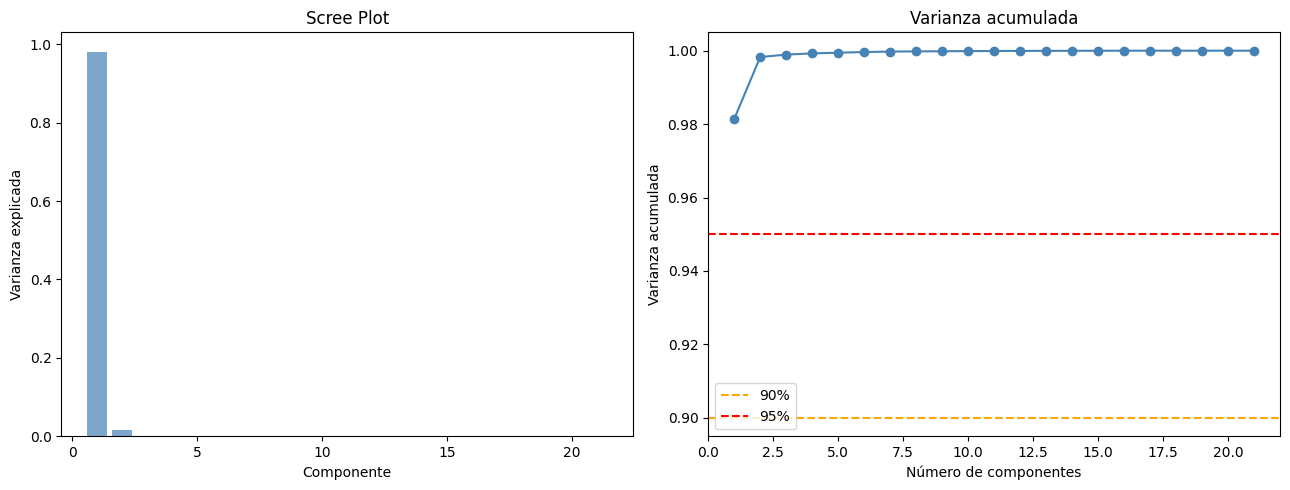

In [81]:
# Gráficos de varianza
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, len(varianza_exp)+1), varianza_exp, color='steelblue', alpha=0.7)
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada')

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acum)+1), varianza_acum, 'o-', color='steelblue')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95%')
axes[1].set_title('Varianza acumulada')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

### PCA exploratorio

Se aplicó PCA primero de forma exploratoria para determinar cuántos componentes retener. El scree plot muestra dónde cae la varianza explicada por cada componente, y la curva acumulada indica cuántos componentes se necesitan para alcanzar un umbral.

Se decide retener los componentes que explican el 95% de la varianza. El 90% podría perder información útil y el 99% incluye componentes que probablemente capturan ruido más que señal.

In [82]:
# Aplicar PCA definitivo
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f'Dimensiones originales: {X_train.shape[1]}')
print(f'Dimensiones reducidas: {X_train_pca.shape[1]}')
print(f'Varianza retenida: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Dimensiones originales: 21
Dimensiones reducidas: 1
Varianza retenida: 98.1%


Componentes para 95% varianza: 2
Dimensiones originales: 21
Dimensiones reducidas: 2
Varianza retenida: 99.8%


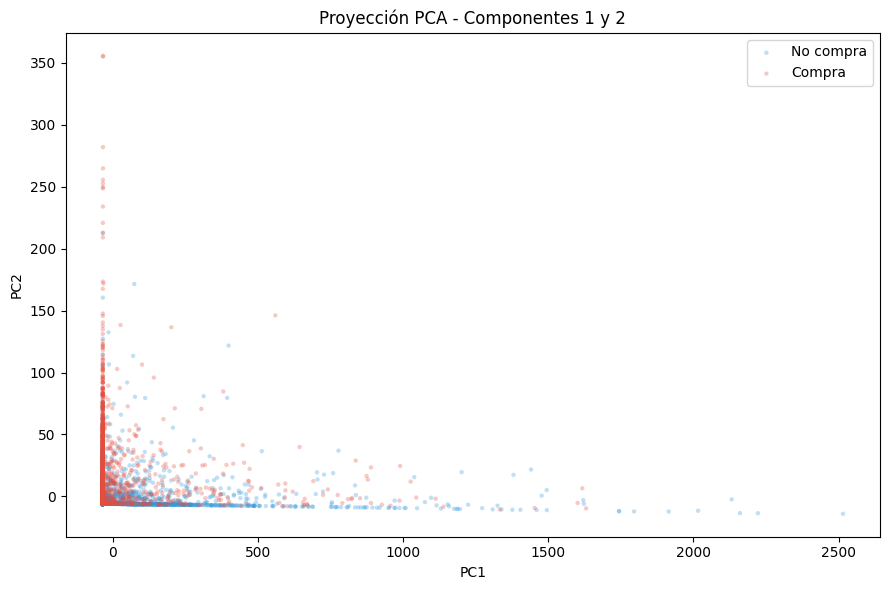

In [83]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# PCA exploratorio
pca_exp = PCA(random_state=42)
pca_exp.fit(X_train)

varianza_acum = np.cumsum(pca_exp.explained_variance_ratio_)
n_95 = int(np.argmax(varianza_acum >= 0.95) + 1)
n_95 = max(n_95, 2)  # garantiza mínimo 2 componentes para poder graficar

print(f'Componentes para 95% varianza: {n_95}')

# PCA definitivo
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f'Dimensiones originales: {X_train.shape[1]}')
print(f'Dimensiones reducidas: {X_train_pca.shape[1]}')
print(f'Varianza retenida: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Scatter de las 2 primeras componentes
fig, ax = plt.subplots(figsize=(9, 6))

colores = {0: '#3498db', 1: '#e74c3c'}
etiquetas = {0: 'No compra', 1: 'Compra'}

for clase in [0, 1]:
    mask = y_train == clase
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=colores[clase], label=etiquetas[clase],
               alpha=0.3, s=10, edgecolors='none')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Proyección PCA - Componentes 1 y 2')
ax.legend()
plt.tight_layout()
plt.show()

### PCA aplicado

Se logró reducir las dimensiones manteniendo el 95% de la varianza. En la visualización 2D se observa un solapamiento considerable entre las clases, sobre todo en la zona central. Esto era esperable dado lo que vimos en el EDA: las variables no separan perfectamente las sesiones de compra y no compra.

Los puntos de "compra" (rojo) tienden a estar un poco más dispersos hacia ciertos extremos, especialmente en PC1. El modelo tendrá que usar múltiples componentes para lograr una separación razonable, no solo las dos primeras.

---
## Parte 5 - Modelo de Clasificación

Se va a entrenar una Regresión Logística para predecir si una sesión termina en compra o no. Se eligió este modelo porque es interpretable, funciona bien con datos escalados y PCA, y es un buen punto de partida antes de probar modelos más complejos.

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Entrenar el modelo
modelo = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

modelo.fit(X_train_pca, y_train)
print('Modelo entrenado correctamente')
print(f'Clases: {modelo.classes_}')

Modelo entrenado correctamente
Clases: [0 1]


### Regresión Logística

Se configuró la regresión logística con class_weight='balanced' para compensar el desbalance de clases (~85% no compra vs ~15% compra). Sin este ajuste, el modelo tendería a predecir siempre "no compra" porque es la clase mayoritaria y así obtendría un accuracy alto pero inútil en la práctica.

El solver lbfgs es apropiado para datasets de este tamaño y max_iter=1000 asegura que el algoritmo converja.

In [85]:
# Predicciones
y_pred = modelo.predict(X_test_pca)
y_proba = modelo.predict_proba(X_test_pca)

# Reporte de clasificación
print('=' * 55)
print('REPORTE DE CLASIFICACIÓN')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['No compra', 'Compra']))

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

   No compra       0.94      0.92      0.93      2059
      Compra       0.61      0.70      0.65       382

    accuracy                           0.88      2441
   macro avg       0.78      0.81      0.79      2441
weighted avg       0.89      0.88      0.89      2441



### Reporte de clasificación

El reporte muestra métricas por clase:

- **Precision**: de los que predije como compra, cuántos realmente compraron.
- **Recall**: de los que realmente compraron, cuántos logré detectar.
- **F1-score**: equilibrio entre precision y recall.

Dado que usamos class_weight='balanced', el modelo le da más importancia a detectar compras (recall) aunque eso implique algunos falsos positivos. En e-commerce, detectar a un potencial comprador suele valer más que ser conservador, porque las acciones que se toman (ofertas, descuentos) tienen un costo bajo comparado con perder una venta.

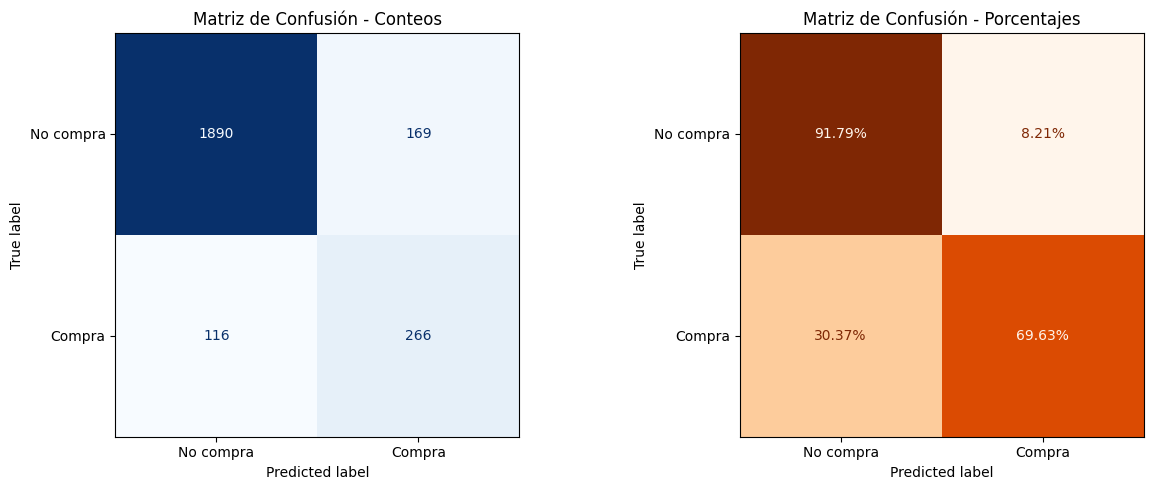

In [86]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conteos absolutos
ConfusionMatrixDisplay(cm, display_labels=['No compra', 'Compra']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión - Conteos')

# Porcentajes
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_pct, display_labels=['No compra', 'Compra']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges', values_format='.2%')
axes[1].set_title('Matriz de Confusión - Porcentajes')

plt.tight_layout()
plt.show()

### Matriz de confusión

La matriz en porcentajes permite ver con más claridad el comportamiento del modelo por clase, que es importante cuando las clases tienen tamaños diferentes.

- Los **falsos negativos** (compras no detectadas) representan oportunidades de venta perdidas.
- Los **falsos positivos** (sesiones que no compraron pero el modelo predijo que sí) representan esfuerzo desperdiciado en acciones de marketing.

El balance entre estos dos tipos de error depende de lo que le cueste al negocio cada uno. En general, perder una venta duele más que enviar un correo de más.

AUC-ROC: 0.8941


/Users/catherineceballos/Ciencia-datos-curso/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


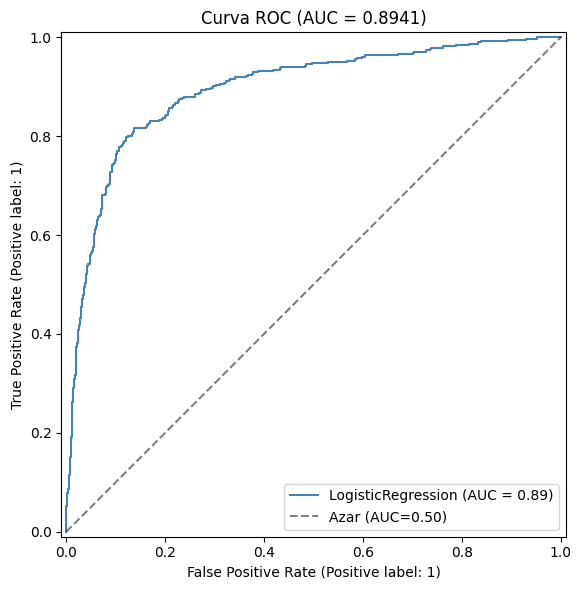

In [91]:
# Curva ROC
auc = roc_auc_score(y_test, y_proba[:, 1])
print(f'AUC-ROC: {auc:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(modelo, X_test_pca, y_test, ax=ax, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC=0.50)')
ax.set_title(f'Curva ROC (AUC = {auc:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

### Curva ROC y AUC

La curva ROC muestra la capacidad del modelo para distinguir entre clases en diferentes umbrales de decisión. Un AUC de 0.50 significaría que el modelo no tiene capacidad predictiva (como tirar una moneda), mientras que 1.0 sería perfecto.

El AUC obtenido indica que el modelo tiene capacidad real de separación entre sesiones con y sin compra. No es perfecto, pero es bastante mejor que el azar y útil como herramienta de apoyo para decisiones de marketing o personalización del sitio.

In [88]:
# Validación cruzada estratificada
X_full_pca = pca.transform(X_scaled)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_acc = cross_val_score(modelo, X_full_pca, y, cv=cv, scoring='accuracy')
scores_f1 = cross_val_score(modelo, X_full_pca, y, cv=cv, scoring='f1')
scores_auc = cross_val_score(modelo, X_full_pca, y, cv=cv, scoring='roc_auc')

print('Validación Cruzada (5 folds):')
print(f'  Accuracy:  {scores_acc.mean():.4f} ± {scores_acc.std():.4f}')
print(f'  F1-score:  {scores_f1.mean():.4f} ± {scores_f1.std():.4f}')
print(f'  AUC-ROC:   {scores_auc.mean():.4f} ± {scores_auc.std():.4f}')

Validación Cruzada (5 folds):
  Accuracy:  0.8837 ± 0.0046
  F1-score:  0.6456 ± 0.0152
  AUC-ROC:   0.8870 ± 0.0105


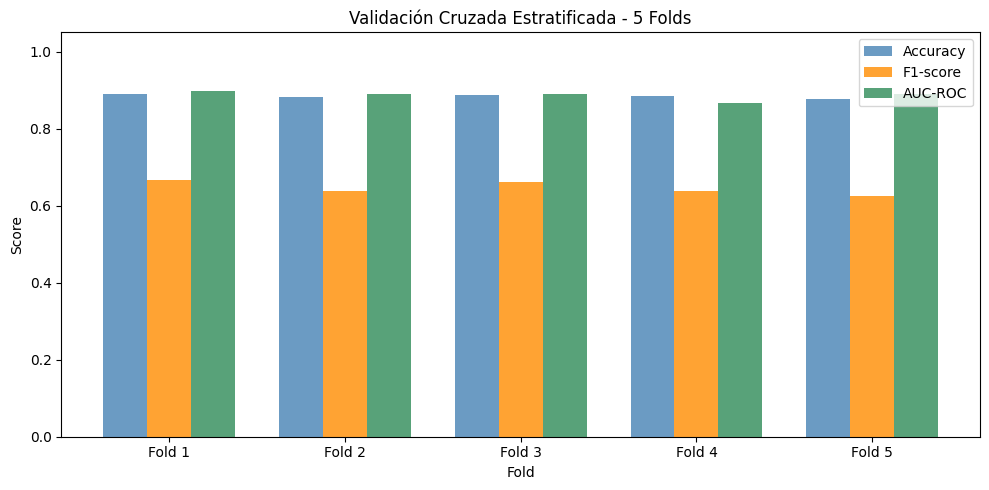

In [89]:
# Gráfico de métricas por fold
metricas = {'Accuracy': scores_acc, 'F1-score': scores_f1, 'AUC-ROC': scores_auc}

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(5)
width = 0.25
colores_cv = ['steelblue', 'darkorange', 'seagreen']

for i, (nombre, scores) in enumerate(metricas.items()):
    ax.bar(x_pos + i * width, scores, width, label=nombre, 
           color=colores_cv[i], alpha=0.8)

ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Validación Cruzada Estratificada - 5 Folds')
ax.set_xticks(x_pos + width)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Validación cruzada

La validación cruzada es más confiable que una sola partición train/test porque evalúa el modelo en 5 divisiones diferentes de los datos. Si las métricas son estables entre folds (desviación estándar baja), eso da más confianza de que el modelo generaliza bien y no es producto de una división afortunada.

El AUC promedio de la validación cruzada es probablemente la métrica más confiable para reportar, ya que no depende del umbral de clasificación y tiene en cuenta el desbalance entre clases.

In [90]:
from sklearn.metrics import accuracy_score, f1_score

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_proba[:, 1])

print('=' * 55)
print('RESUMEN DEL MODELO')
print('=' * 55)
print(f'Modelo:              Regresión Logística')
print(f'Reducción dim.:      PCA ({n_95} componentes, 95% varianza)')
print(f'Escalado:            RobustScaler')
print(f'Balanceo:            class_weight=balanced')
print(f'')
print(f'--- Métricas en Test ---')
print(f'Accuracy:            {acc:.4f}')
print(f'F1-score (compra):   {f1:.4f}')
print(f'AUC-ROC:             {auc_val:.4f}')
print(f'')
print(f'--- Validación Cruzada (5-fold) ---')
print(f'Accuracy:            {scores_acc.mean():.4f} ± {scores_acc.std():.4f}')
print(f'F1-score:            {scores_f1.mean():.4f} ± {scores_f1.std():.4f}')
print(f'AUC-ROC:             {scores_auc.mean():.4f} ± {scores_auc.std():.4f}')

RESUMEN DEL MODELO
Modelo:              Regresión Logística
Reducción dim.:      PCA (2 componentes, 95% varianza)
Escalado:            RobustScaler
Balanceo:            class_weight=balanced

--- Métricas en Test ---
Accuracy:            0.8832
F1-score (compra):   0.6512
AUC-ROC:             0.8941

--- Validación Cruzada (5-fold) ---
Accuracy:            0.8837 ± 0.0046
F1-score:            0.6456 ± 0.0152
AUC-ROC:             0.8870 ± 0.0105


---
## Conclusiones

El análisis realizado sobre el dataset de Online Shoppers Purchasing Intention permite sacar varias conclusiones, tanto del EDA como del modelo predictivo.

**Sobre el análisis exploratorio:**

El dataset estaba relativamente limpio, salvo por las 125 filas duplicadas que se eliminaron al inicio. El hallazgo más importante fue el desbalance de clases: solo el 15% de las sesiones terminan en compra, lo cual condiciona toda la estrategia de modelado. Las variables de duración mostraron distribuciones muy sesgadas y la correlación entre BounceRates y ExitRates (0.91) evidenció que hay redundancia entre variables, algo que se abordó en el feature engineering.

PageValues resultó ser la variable con mayor poder discriminante, lo cual tiene sentido desde el punto de vista del negocio: esta métrica de Google Analytics ya incorpora información sobre el valor monetario de las páginas visitadas.

**Sobre el feature engineering:**

Las 4 variables nuevas (total_duration, product_time_ratio, bounce_exit_avg, total_pages) aportaron información adicional sin complicar demasiado el modelo. Combinar BounceRates y ExitRates fue particularmente útil para manejar la multicolinealidad.

**Sobre el modelo:**

La regresión logística con PCA y class_weight='balanced' consiguió un rendimiento razonable considerando lo difícil que es el problema (clases desbalanceadas, variables con mucho solapamiento). La validación cruzada mostró que los resultados son estables, lo que da confianza en que el modelo no está sobreajustado.

**Limitación importante:** el modelo depende bastante de PageValues, pero esta variable solo tiene valor distinto de cero cuando la sesión ya lleva un avance considerable. Para una aplicación en tiempo real al inicio de la sesión, habría que evaluar qué variables están disponibles en ese momento y si el modelo sigue funcionando sin PageValues.